<a href="https://colab.research.google.com/github/23071234-coder/NNDL/blob/main/Prac8_NNDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)
Flattened training data shape: (60000, 784)
Flattened testing data shape: (10000, 784)

Autoencoder Model:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)


Training Autoencoder...
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.2414 - val_loss: 0.1646
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1509 - val_loss: 0.1367
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1312 - val_loss: 0.1244
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.1217 - val_loss: 0.1167
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1157 - val_loss: 0.1122
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1116 - val_loss: 0.1088
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1085 - val_loss: 0.1055
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1059 - val_loss: 0.1036
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1038 - val_loss: 0.1020
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1021 - val_loss: 0.1003
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1005 - val_loss: 0.0985
Epoch 12/20
235/23

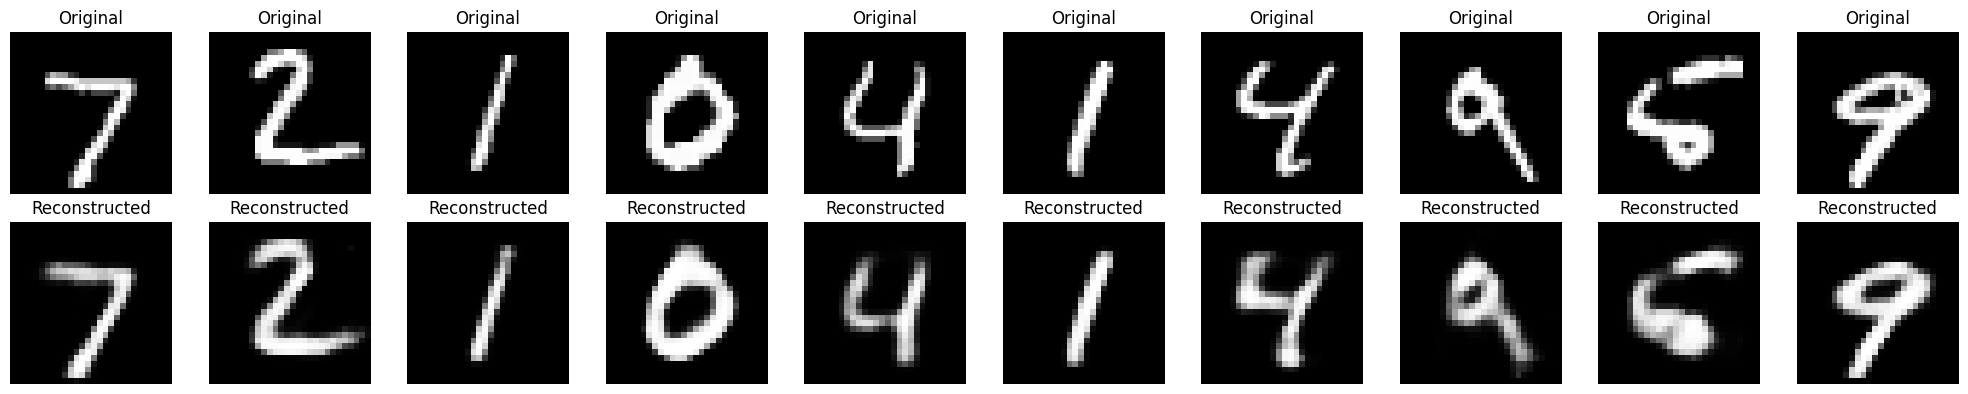

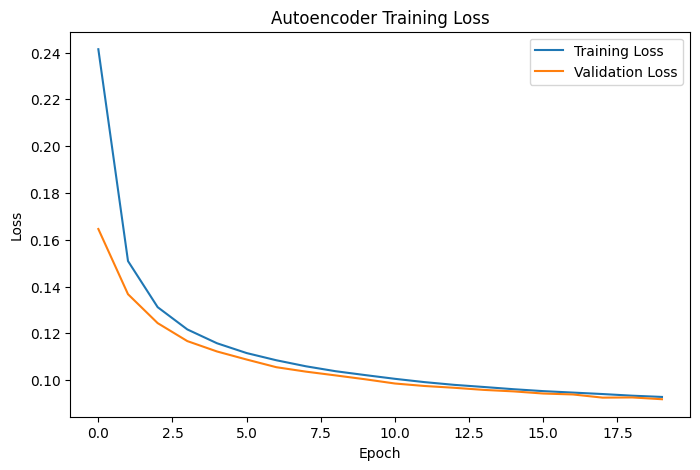

In [ ]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam


# 1. Load Dataset

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


# 2. Normalize Data

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


# 3. Flatten Images

X_train = X_train.reshape(
    X_train.shape[0],
    784
)

X_test = X_test.reshape(
    X_test.shape[0],
    784
)

print("Flattened training data shape:", X_train.shape)
print("Flattened testing data shape:", X_test.shape)


# 4. Define Input and Latent Dimension

input_dim = 784
encoding_dim = 32

input_layer = Input(shape=(input_dim,))


# 5. Build Encoder

encoder_layer = Dense(
    128,
    activation="relu"
)(input_layer)

encoder_layer = Dense(
    64,
    activation="relu"
)(encoder_layer)

encoded = Dense(
    encoding_dim,
    activation="relu"
)(encoder_layer)


# 6. Build Decoder

decoder_layer = Dense(
    64,
    activation="relu"
)(encoded)

decoder_layer = Dense(
    128,
    activation="relu"
)(decoder_layer)

decoded = Dense(
    input_dim,
    activation="sigmoid"
)(decoder_layer)


# 7. Create Autoencoder

autoencoder = Model(
    input_layer,
    decoded
)


# 8. Create Encoder Model

encoder = Model(
    input_layer,
    encoded
)


# 9. Compile Autoencoder

autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy"
)


# 10. Display Model

print("\nAutoencoder Model:")
autoencoder.summary()


# 11. Train Autoencoder

print("\nTraining Autoencoder...")

history = autoencoder.fit(
    X_train,
    X_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test, X_test),
    verbose=1
)


# 12. Evaluate Autoencoder

test_loss = autoencoder.evaluate(
    X_test,
    X_test,
    verbose=0
)

print("\nReconstruction Loss:", round(test_loss, 4))


# 13. Perform Dimensionality Reduction

X_train_encoded = encoder.predict(
    X_train,
    verbose=0
)

X_test_encoded = encoder.predict(
    X_test,
    verbose=0
)

print("\nOriginal feature dimensions:", X_train.shape[1])
print("Reduced feature dimensions:", X_train_encoded.shape[1])


# 14. Display Some Encoded Features

print("\nFirst 5 encoded samples:")

print(X_test_encoded[:5])


# 15. Reconstruct Test Images

X_test_decoded = autoencoder.predict(
    X_test,
    verbose=0
)


# 16. Calculate Reconstruction Error

reconstruction_error = np.mean(
    np.square(
        X_test - X_test_decoded
    )
)

print("\nAverage Reconstruction Error:",
      round(reconstruction_error, 6))


# 17. Compare Original and Reconstructed Image

import matplotlib.pyplot as plt

n = 10

plt.figure(figsize=(20, 4))

for i in range(n):

    # Original image
    ax = plt.subplot(2, n, i + 1)

    plt.imshow(
        X_test[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title("Original")
    plt.axis("off")

    # Reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)

    plt.imshow(
        X_test_decoded[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()


# 18. Plot Training Loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training Loss")

plt.legend()
plt.show()
